# **Tugas 2 data_understanding**
## **Penjelasan Outlier Deteksi**
### **Deteksi Outlier dengan K-Nearest Neighbors (KNN) dalam Data Understanding**  
#### 1. Pengantar Outlier dalam Data Understanding
Outlier adalah titik data yang memiliki nilai yang sangat berbeda dari sebagian besar data dalam suatu dataset. Nilai-nilai ini bisa muncul karena berbagai alasan, seperti kesalahan pengukuran, kesalahan input data, atau karena fenomena langka yang memang terjadi. Dalam tahap Data Understanding, mendeteksi outlier sangat penting karena keberadaan outlier dapat memengaruhi hasil analisis, pemodelan, dan pengambilan keputusan. Outlier yang tidak terdeteksi dapat menyebabkan model statistik atau machine learning menjadi bias, tidak akurat, atau bahkan gagal dalam memberikan hasil yang valid.

#### 2. Konsep K-Nearest Neighbors (KNN) dalam Deteksi Outlier
K-Nearest Neighbors (KNN) adalah salah satu algoritma yang dapat digunakan untuk mendeteksi outlier. Algoritma ini bekerja berdasarkan prinsip bahwa data normal cenderung berada dalam kelompok yang padat, sementara outlier cenderung berada jauh dari kelompok tersebut. Berikut adalah konsep dasar KNN dalam deteksi outlier:


*   Prinsip Kerja KNN:



KNN menghitung jarak antara suatu titik data dengan titik-titik data lain di sekitarnya. Titik data yang memiliki jarak jauh dari sebagian besar tetangganya dianggap sebagai outlier.
Secara matematis, KNN mengukur jarak (misalnya, Euclidean, Manhattan, atau Minkowski) antara titik data dan k-tetangga terdekatnya. Jika jarak rata-rata ke k-tetangga terdekat tersebut lebih besar dari ambang batas tertentu, titik data tersebut dianggap sebagai outlier.

#### Kapan Menggunakan KNN untuk Deteksi Outlier?
KNN adalah metode yang efektif untuk deteksi outlier dalam situasi berikut:

Data Berdimensi Tinggi:
KNN dapat bekerja dengan baik pada data yang memiliki banyak fitur (dimensi tinggi), meskipun performanya mungkin menurun jika dimensi terlalu tinggi karena "curse of dimensionality".

Data Tanpa Asumsi Distribusi:
KNN tidak memerlukan asumsi tentang distribusi data, sehingga cocok untuk data yang tidak mengikuti distribusi normal atau distribusi tertentu.

Dataset dengan Ukuran Sedang:
KNN cocok untuk dataset yang tidak terlalu besar karena kompleksitas komputasinya yang meningkat seiring dengan jumlah data. Untuk dataset yang sangat besar, metode lain seperti Local Outlier Factor (LOF) atau Isolation Forest mungkin lebih efisien.


#### Kesimpulan
K-Nearest Neighbors (KNN) adalah metode yang efektif untuk mendeteksi outlier, terutama dalam tahap Data Understanding. Metode ini mengandalkan prinsip jarak untuk mengidentifikasi titik data yang berbeda secara signifikan dari sebagian besar data. Meskipun memiliki kelebihan seperti fleksibilitas dan kemudahan implementasi, KNN juga memiliki keterbatasan, terutama dalam hal komputasi dan pemilihan parameter. Oleh karena itu, penting untuk mempertimbangkan karakteristik dataset dan kebutuhan analisis sebelum memutuskan menggunakan KNN untuk deteksi outlier.

Dalam praktiknya, KNN sering digunakan bersama dengan teknik lain seperti visualisasi data (misalnya, scatter plot atau box plot) untuk memvalidasi hasil deteksi outlier dan memastikan kualitas data yang lebih baik sebelum melanjutkan ke tahap pemodelan.

In [27]:
%pip install pymysql
%pip install psycopg2


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Kode di bawah mengimpor berbagai pustaka yang digunakan untuk analisis data, visualisasi, dan pembelajaran mesin. **`psycopg2`** dan **`pymysql`** digunakan untuk berinteraksi dengan database PostgreSQL dan MySQL. **`numpy`** dan **`pandas`** berfungsi untuk manipulasi data numerik dan tabel. **`seaborn`** dan **`matplotlib.pyplot`** digunakan untuk visualisasi data. **`scipy.spatial.distance.euclidean`** memungkinkan perhitungan jarak Euclidean antara dua titik. Sementara itu, **`sklearn.neighbors.NearestNeighbors`** digunakan untuk membangun model tetangga terdekat dalam pembelajaran mesin, sering digunakan dalam clustering atau rekomendasi berbasis kedekatan.

In [28]:
import psycopg2
import pymysql
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from sklearn.neighbors import NearestNeighbors

Fungsi **`get_pg_data()`** digunakan untuk mengambil data dari tabel **`iris_postgresql`** yang tersimpan dalam database PostgreSQL. Fungsi ini pertama-tama membuat koneksi ke database menggunakan **`psycopg2.connect()`**, dengan parameter seperti **host**, **user**, **password**, **database**, dan **port** yang diperlukan untuk autentikasi. Setelah koneksi berhasil, fungsi membuat **cursor** untuk mengeksekusi perintah SQL **`SELECT * FROM iris_postgresql`**, yang mengambil semua data dari tabel tersebut. Hasil query kemudian diambil menggunakan **`fetchall()`**, dan daftar nama kolom diekstrak dari **`cursor.description`**. Setelah semua data diperoleh, koneksi ditutup, dan data dikembalikan dalam bentuk **`pandas.DataFrame`** agar lebih mudah untuk dianalisis dan dimanipulasi.

In [29]:
def get_pg_data():
    conn = psycopg2.connect(
        host="sepaliris-bungairis.i.aivencloud.com",
        user="avnadmin",
        password="AVNS_suHRtx1E78VwD_GpUWU",
        database="defaultdb",
        port=21375
    )
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM iris_postgresql")
    data = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]
    cursor.close()
    conn.close()
    return pd.DataFrame(data, columns=columns)

Fungsi **`get_mysql_data()`** digunakan untuk mengambil data dari tabel **`irismysql`** yang tersimpan dalam database MySQL. Fungsi ini membuat koneksi ke database menggunakan **`pymysql.connect()`**, dengan parameter seperti **host**, **user**, **password**, **database**, dan **port** untuk autentikasi. Setelah koneksi berhasil, fungsi membuat **cursor** untuk mengeksekusi perintah SQL **`SELECT * FROM irismysql`**, yang mengambil semua data dari tabel tersebut. Hasil query diambil menggunakan **`fetchall()`**, dan nama kolom diekstrak dari **`cursor.description`**. Setelah itu, koneksi ditutup, dan data dikembalikan dalam bentuk **`pandas.DataFrame`** agar lebih mudah untuk dianalisis dan dimanipulasi.

In [30]:
def get_mysql_data():
    conn = pymysql.connect(
        host="mysql-3c52fb68-bungairis.i.aivencloud.com",
        user="avnadmin",
        password="AVNS_dKrJFht6v0jbq0m01NJ",
        database="defaultdb",
        port=21375
    )
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM irismysql")
    data = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]
    cursor.close()
    conn.close()
    return pd.DataFrame(data, columns=columns)

Kode ini melakukan deteksi outlier menggunakan algoritma **K-Nearest Neighbors (KNN)** dengan terlebih dahulu mengambil data dari dua database (PostgreSQL dan MySQL), lalu menggabungkannya berdasarkan kolom **"id"** dan **"class"**. Selanjutnya, kode mengekstrak fitur numerik seperti **"petal_length"**, **"petal_width"**, **"sepal_length"**, dan **"sepal_width"** untuk analisis lebih lanjut. Model KNN dengan metrik **Euclidean** dibuat dengan **K = 5**, dan jarak rata-rata ke 5 tetangga terdekat dihitung untuk setiap data. Outlier ditentukan berdasarkan threshold **persentil ke-95** dari jarak tersebut, di mana data yang memiliki jarak lebih besar dianggap sebagai outlier. Hasil akhir dicetak dalam bentuk tabel, dan scatter plot divisualisasikan untuk menunjukkan distribusi data dengan outlier berwarna merah dan data normal berwarna biru.

 id           class  petal_length  petal_width  sepal_length  sepal_width  knn_distance  outlier
  1     Iris-setosa           1.4          0.2           5.1          3.5      0.133137    False
  2     Iris-setosa          14.0          2.0          40.9         30.0     17.738116     True
  3     Iris-setosa           1.3          0.2           4.7          3.2      0.247029    False
  4     Iris-setosa          15.0         20.0          46.0         31.0     16.562214     True
  5     Iris-setosa           1.4          0.2           5.0          3.6      0.191277    False
  6     Iris-setosa           1.7          0.4           5.4          3.9      0.360018    False
  7     Iris-setosa           1.4          0.3           4.6          3.4      0.308980    False
  8     Iris-setosa           1.5          0.2           5.0          3.4      0.167647    False
  9     Iris-setosa           1.4          0.2           4.4          2.9      0.317776    False
 10     Iris-setosa           

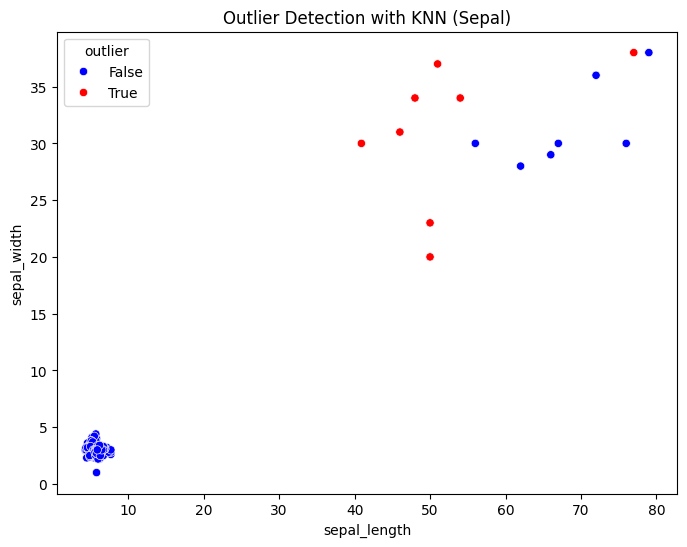

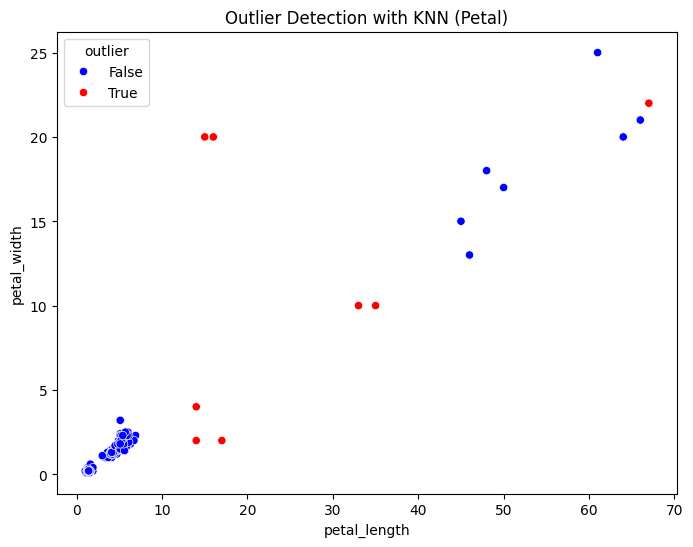

In [31]:
# Ambil data dari kedua database
df_postgresql = get_pg_data()
df_mysql = get_mysql_data()

# Gabungkan berdasarkan kolom 'id' dan 'Class'
df_merged = pd.merge(df_mysql, df_postgresql, on=["id", "class"], how="inner")

# Ambil data fitur numerik
feature_columns = ["petal_length", "petal_width", "sepal_length", "sepal_width"]
data_values = df_merged[feature_columns].values

# Gunakan KNN untuk mendeteksi outlier
K = 5  # Jumlah tetangga terdekat
nbrs = NearestNeighbors(n_neighbors=K+1, metric='euclidean').fit(data_values)
distances, indices = nbrs.kneighbors(data_values)

# Ambil rata-rata jarak ke K tetangga terdekat (tidak termasuk jarak ke dirinya sendiri)
df_merged["knn_distance"] = np.mean(distances[:, 1:], axis=1)

# Tentukan threshold outlier berdasarkan persentil ke-95
threshold = np.percentile(df_merged["knn_distance"], 95)
df_merged["outlier"] = df_merged["knn_distance"] > threshold

# Cetak hasil data dengan outlier
print(df_merged.to_string(index=False))

# Visualisasi scatter plot dengan warna berdasarkan outlier
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_merged["sepal_length"], y=df_merged["sepal_width"],
    hue=df_merged["outlier"], palette={False: "blue", True: "red"}
)
plt.title("Outlier Detection with KNN (Sepal)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_merged["petal_length"], y=df_merged["petal_width"],
    hue=df_merged["outlier"], palette={False: "blue", True: "red"}
)
plt.title("Outlier Detection with KNN (Petal)")
plt.show()

###Digunakan untuk menghitung total jumlah outlier yang terdeteksi dalam dataset

In [32]:
# Hitung total outlier
total_outliers = df_merged["outlier"].sum()
print(f"Total Outlier: {total_outliers}")


Total Outlier: 8


##### Menampilkan daftar outlier yang terdeteksi


In [33]:
# Urutkan data berdasarkan jarak dari terkecil ke terbesar
df_sorted = df_merged.sort_values(by="knn_distance", ascending=True)

# Tampilkan hasilnya
print(df_sorted.to_string(index=False))

 id           class  petal_length  petal_width  sepal_length  sepal_width  knn_distance  outlier
 10     Iris-setosa           1.5          0.1           4.9          3.1      0.109282    False
 35     Iris-setosa           1.5          0.1           4.9          3.1      0.109282    False
 38     Iris-setosa           1.5          0.1           4.9          3.1      0.109282    False
  1     Iris-setosa           1.4          0.2           5.1          3.5      0.133137    False
 40     Iris-setosa           1.5          0.2           5.1          3.4      0.139494    False
 18     Iris-setosa           1.4          0.3           5.1          3.5      0.152207    False
 28     Iris-setosa           1.5          0.2           5.2          3.5      0.164215    False
 29     Iris-setosa           1.4          0.2           5.2          3.4      0.164215    False
  8     Iris-setosa           1.5          0.2           5.0          3.4      0.167647    False
 31     Iris-setosa           

#### Memisahkan outlier dari data

In [34]:
import psycopg2
import pymysql
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay

def get_pg_data():
    conn = psycopg2.connect(
        host="pg-33e8099d-mysqlemi.i.aivencloud.com",
        user="avnadmin",
        password="AVNS_GPVkFx92UyzKptom2fE",
        database="defaultdb",
        port=21897
    )
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM iris_postgresql")
    data = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]
    cursor.close()
    conn.close()
    return pd.DataFrame(data, columns=columns)

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Pisahkan fitur dan label
X = df_merged[feature_columns]
y = df_merged["class"]

# Encode label kelas ke numerik
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Menerapkan LOF untuk deteksi outlier
lof = LocalOutlierFactor(n_neighbors=90, contamination=0.1)
outlier_labels = lof.fit_predict(X)
df_merged["outlier"] = outlier_labels

# Pisahkan data dengan outlier dan tanpa outlier
df_cleaned = df_merged[df_merged["outlier"] == 1].drop(columns=["outlier"])

# Membagi data menjadi training (80%) dan testing (20%) untuk data dengan outlier
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Fit ulang LabelEncoder setelah menghapus outlier
label_encoder_clean = LabelEncoder()
df_cleaned["class"] = label_encoder_clean.fit_transform(df_cleaned["class"])

# Membagi data menjadi training dan testing untuk data tanpa outlier
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    df_cleaned[feature_columns],
    df_cleaned["class"],
    test_size=0.2,
    random_state=42
)

# Pipeline dengan StandardScaler dan KNN
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=11))
])

# Latih model pada data dengan outlier
knn_pipeline.fit(X_train_all, y_train_all)
y_pred_all = knn_pipeline.predict(X_test_all)
accuracy_all = accuracy_score(y_test_all, y_pred_all)
print("Akurasi dengan outlier:", accuracy_all)

# Pastikan hanya kelas yang ada digunakan dalam laporan klasifikasi
print(classification_report(y_test_all, y_pred_all, target_names=label_encoder.classes_[np.unique(y_test_all)]))

# Latih model pada data tanpa outlier
knn_pipeline.fit(X_train_clean, y_train_clean)
y_pred_clean = knn_pipeline.predict(X_test_clean)
accuracy_clean = accuracy_score(y_test_clean, y_pred_clean)
print("Akurasi tanpa outlier:", accuracy_clean)

# Pastikan hanya kelas yang ada digunakan dalam laporan klasifikasi
print(classification_report(y_test_clean, y_pred_clean, target_names=label_encoder_clean.classes_[np.unique(y_test_clean)]))

# Ambil data dari kedua database
df_postgresql = get_pg_data()
df_mysql = get_mysql_data()

# Gabungkan berdasarkan kolom 'id' dan 'class'
df_merge = pd.merge(df_mysql, df_postgresql, on=["id", "class"], how="inner")

# Ambil data fitur numerik tanpa kolom 'class'
feature_columns = ["petal_length", "petal_width", "sepal_length", "sepal_width"]
data_values = df_merge[feature_columns].values

# Inisialisasi model LOF
clf = LocalOutlierFactor(n_neighbors=90)
label = clf.fit_predict(data_values)

# Tambahkan hasil label ke dataframe
df_merge["outlier_label"] = label

# Cetak hasil dengan ID dan class
print(df_merge.to_string(index=False))

num_outliers = (label == -1).sum()
print(f"\nJumlah outlier: {num_outliers}")
df_filtered = df_merge[label == 1].drop(columns=["outlier_label"], errors='ignore')
outliers = df_merge[label == -1].drop(columns=["outlier_label"], errors='ignore')
print("\nData Outlier:")
print(outliers.to_string(index=False))
print("\nJumlah data setelah dihapus : ",len(df_filtered))
print("\nData tidak outlier :")
print(df_filtered.to_string(index=False))

Akurasi dengan outlier: 0.967741935483871
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.92      1.00      0.96        11
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        31
      macro avg       0.97      0.96      0.97        31
   weighted avg       0.97      0.97      0.97        31

Akurasi tanpa outlier: 0.9642857142857143
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.96        28
      macro avg       0.95      0.96      0.95        28
   weighted avg       0.97      0.96      0.96        28

 id           class  petal_length  petal_width  sepal_length  sepal_width  outlier_label
  1     Iris-setosa    

Kode ini menghubungkan dua basis data (PostgreSQL dan MySQL) untuk mengambil data dari tabel iris_postgresql dan irismysql. Data dari kedua tabel digabungkan berdasarkan kolom id dan class menggunakan metode inner join, sehingga hanya data yang ada di kedua tabel yang dipertahankan.

Selanjutnya, fitur numerik seperti petal_length, petal_width, sepal_length, dan sepal_width digunakan dalam deteksi outlier menggunakan model Local Outlier Factor (LOF) dengan n_neighbors=90. Model ini memberikan label 1 untuk data normal dan -1 untuk data outlier.

Hasil deteksi outlier ditambahkan ke DataFrame dengan kolom outlier_label. Data dengan label -1 dianggap outlier, sementara yang berlabel 1 dianggap normal. Data normal disimpan dalam variabel `df_filtered`, sedangkan outlier disimpan dalam variabel `outliers`.

Terakhir, jumlah total outlier dan data yang tersisa setelah pembersihan ditampilkan. Pendekatan ini membantu membersihkan data dari outlier sebelum analisis lebih lanjut, sehingga meningkatkan kualitas hasil analisis atau model pembelajaran mesin.

#### Menghitung akurasi data

In [35]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Pisahkan fitur dan label
X = df_merged[feature_columns]
y = df_merged["class"]

# Encode label kelas ke numerik
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Menerapkan LOF untuk deteksi outlier
lof = LocalOutlierFactor(n_neighbors=90, contamination=0.1)
outlier_labels = lof.fit_predict(X)
df_merged["outlier"] = outlier_labels

# Pisahkan data dengan outlier dan tanpa outlier
df_cleaned = df_merged[df_merged["outlier"] == 1].drop(columns=["outlier"])

# Membagi data menjadi training (80%) dan testing (20%) untuk data dengan outlier
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Fit ulang LabelEncoder setelah menghapus outlier
label_encoder_clean = LabelEncoder()
df_cleaned["class"] = label_encoder_clean.fit_transform(df_cleaned["class"])

# Membagi data menjadi training dan testing untuk data tanpa outlier
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    df_cleaned[feature_columns],
    df_cleaned["class"],
    test_size=0.2,
    random_state=42
)

# Pipeline dengan StandardScaler dan KNN
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=11))
])

# Latih model pada data dengan outlier
knn_pipeline.fit(X_train_all, y_train_all)
y_pred_all = knn_pipeline.predict(X_test_all)
accuracy_all = accuracy_score(y_test_all, y_pred_all)
print("Akurasi dengan outlier:", accuracy_all)

# Pastikan hanya kelas yang ada digunakan dalam laporan klasifikasi
print(classification_report(y_test_all, y_pred_all, target_names=label_encoder.classes_[np.unique(y_test_all)]))

# Latih model pada data tanpa outlier
knn_pipeline.fit(X_train_clean, y_train_clean)
y_pred_clean = knn_pipeline.predict(X_test_clean)
accuracy_clean = accuracy_score(y_test_clean, y_pred_clean)
print("Akurasi tanpa outlier:", accuracy_clean)

# Pastikan hanya kelas yang ada digunakan dalam laporan klasifikasi
print(classification_report(y_test_clean, y_pred_clean, target_names=label_encoder_clean.classes_[np.unique(y_test_clean)]))

Akurasi dengan outlier: 0.967741935483871
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.92      1.00      0.96        11
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        31
      macro avg       0.97      0.96      0.97        31
   weighted avg       0.97      0.97      0.97        31

Akurasi tanpa outlier: 0.9642857142857143
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.96        28
      macro avg       0.95      0.96      0.95        28
   weighted avg       0.97      0.96      0.96        28



Kode ini membandingkan akurasi model KNN pada data yang mengandung outlier dan data yang sudah dibersihkan dari outlier.  

Data numerik diekstrak, label kelas dikonversi ke angka, lalu outlier dideteksi menggunakan Local Outlier Factor (LOF) dengan parameter n_neighbors=90 dan contamination=0.1. Dataset dibagi menjadi data pelatihan (80%) dan pengujian (20%) dengan train_test_split.  

Model KNN dengan 11 tetangga diterapkan, lalu akurasi dan classification report dihitung untuk data dengan dan tanpa outlier. Hasilnya membantu melihat apakah membersihkan outlier dapat meningkatkan akurasi model.